# Phase 1: GameScope Data Visualization

The point of this phase is to understand the structure of the data available to us via Twitch’s Internet Game Database (IGDB). By understanding the data better, we can gain insights into the best way to leverage it to provide predictive recommendations and data-driven insights. This includes exploring the schema, relationships between entities (games, genres, platforms, companies, and themes), and evaluating data quality and coverage. The findings from this phase will directly inform feature selection, data modeling decisions, and visualization strategies used in later phases of the recommendation system and greater application

## IGDB Data Collected

We pulled in data from the IGDB database using a script written in go. The schema of the records is added below:

```go
type Game struct {		// need to change these maybe?
	ID                 int     `json:"id"`
	Name               string  `json:"name"`
	FirstReleaseDate   int64   `json:"first_release_date"`
	Genres             []int   `json:"genres"`
	Platforms          []int   `json:"platforms"`
	Themes             []int   `json:"themes"`
	Rating             float64 `json:"rating"`
	RatingCount        int     `json:"rating_count"`
	TotalRating        float64 `json:"total_rating"`
	TotalRatingCount   int     `json:"total_rating_count"`
	Summary            string  `json:"summary"`
	Storyline          string  `json:"storyline"`
}
```

In [15]:
# Import Libraries
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
import os
import json
import pickle
from pathlib import Path

In [16]:
# Setup
SCRIPT_DIR = Path(__file__).parent.resolve() if "__file__" in globals() else Path.cwd()
IGDB_ENUM_DIR = SCRIPT_DIR / "igdb_enum"
IGDB_ENUM_DIR.mkdir(exist_ok=True)
print(f"Using igdb_enum directory: {IGDB_ENUM_DIR}")

# === CONFIGURATION ===
BUILD_VISUALIZATION = True  # Set to False to skip data exploration graphs and heatmaps
                            # (Embedding visualizations will always be generated)
print(f"BUILD_VISUALIZATION: {BUILD_VISUALIZATION}")

Using igdb_enum directory: /home/joseph/GameScope/data_visualization/igdb_enum
BUILD_VISUALIZATION: True


In [17]:
def load_data(filename):
    # Load CSV
    df = pd.read_csv(filename)

    # Columns that contain comma-separated integers
    list_cols = ["genres", "platforms", "themes"]

    # Convert comma-separated strings to lists, empty string -> empty list
    for col in list_cols:
        df[col] = (
            df[col]
            .fillna("")  # handle empty cells
            .apply(lambda x: [int(v) for v in x.split(",")] if x else [])
        )

    # Replace empty strings in other columns with NA
    df = df.replace("", pd.NA)

    # Treat 0 as missing in rating columns
    rating_cols = [
        "rating",
        "rating_count",
        "total_rating",
        "total_rating_count"
    ]
    for col in rating_cols:
        df.loc[df[col] == 0, col] = pd.NA

    return df, list_cols, rating_cols

# Load and preprocess
df, list_cols, rating_cols = load_data("../data_collection/out/igdb_games_all.csv")

### Understanding Data Integrity

We want to know where the data has null values

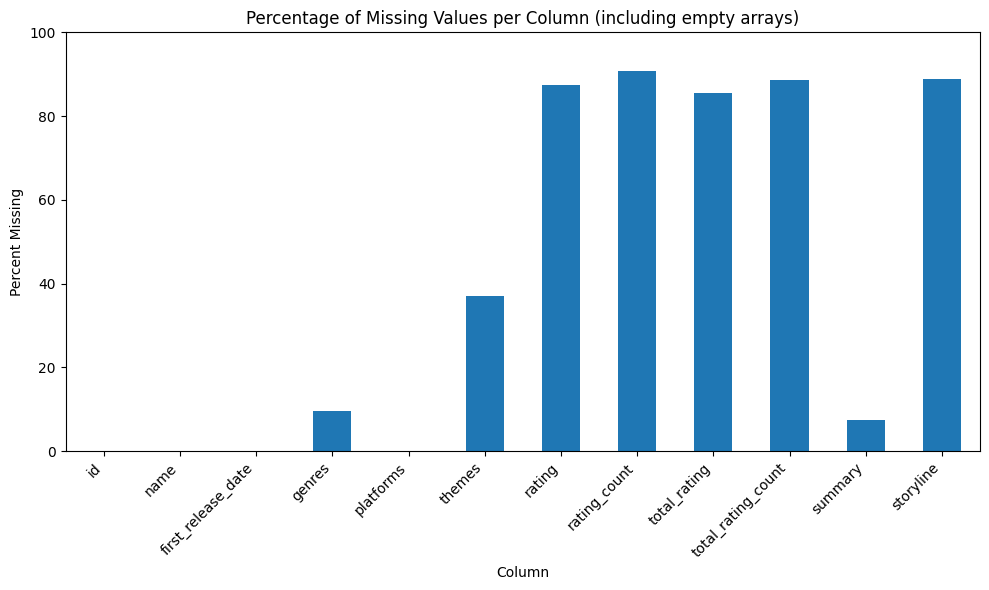

In [18]:
if BUILD_VISUALIZATION:
    # Compute missing percentages
    null_pct = {}
    for col in df.columns:
        if col in list_cols:
            # Consider empty lists as missing
            null_pct[col] = df[col].apply(lambda x: len(x) == 0).mean() * 100
        else:
            null_pct[col] = df[col].isna().mean() * 100

    # Convert to Series for plotting
    null_pct = pd.Series(null_pct)

    # Plot missing percentages
    plt.figure(figsize=(10, 6))
    null_pct.plot(kind="bar")
    plt.title("Percentage of Missing Values per Column (including empty arrays)")
    plt.ylabel("Percent Missing")
    plt.xlabel("Column")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping missing data visualization (BUILD_VISUALIZATION=False)")

### Data Columns

Investigating the specific columns and what that data looks like

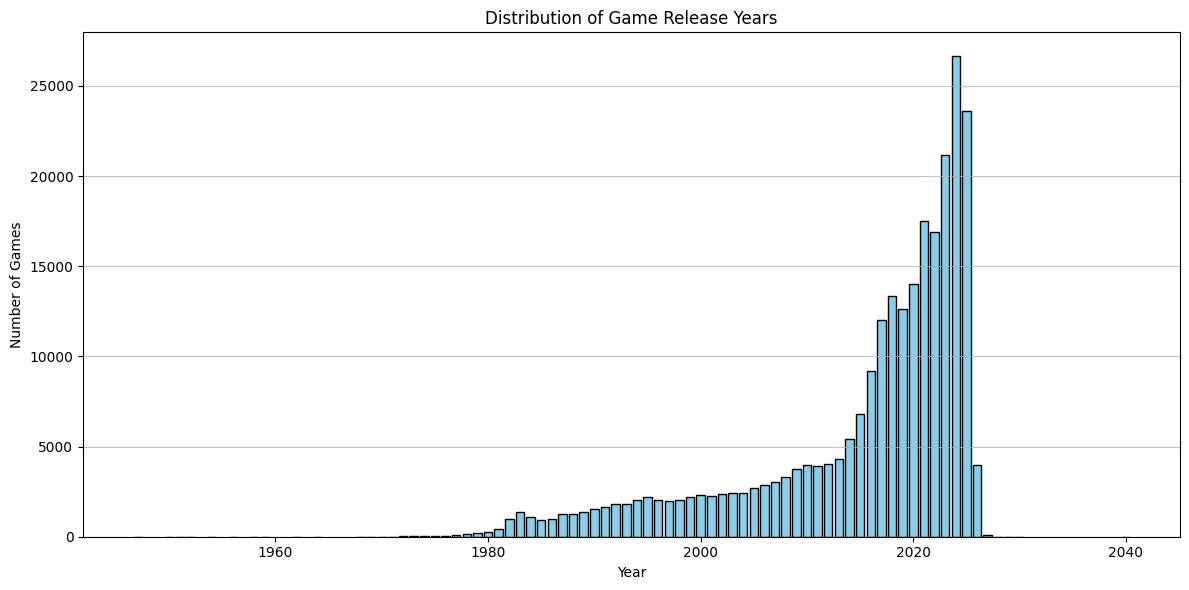

In [19]:
if BUILD_VISUALIZATION:
    '''
    Plot distribution of game release years
    '''
    
    # Convert to datetime
    df['first_release_date'] = pd.to_datetime(df['first_release_date'], errors='coerce')
    df_dates = df.dropna(subset=['first_release_date'])
    
    # Extract year
    df_dates['release_year'] = df_dates['first_release_date'].dt.year
    
    # Count games per year
    year_counts = df_dates['release_year'].value_counts().sort_index()
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.bar(year_counts.index, year_counts.values, color='skyblue', edgecolor='black')
    plt.title('Distribution of Game Release Years')
    plt.xlabel('Year')
    plt.ylabel('Number of Games')
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping release year distribution visualization (BUILD_VISUALIZATION=False)")

In [20]:
'''
Fetch and cache IGDB enumerations (genres, themes, platforms)
'''

def fetch_and_cache_igdb_data(endpoint, cache_file):
    """Fetch IGDB data and cache as JSON to avoid repeated API calls."""
    cache_path = IGDB_ENUM_DIR / cache_file
    
    # Return cached data if available
    if cache_path.exists():
        print(f"Loading cached {endpoint} from {cache_file}")
        with open(cache_path, 'r') as f:
            data = json.load(f)
            # Convert string keys to integers for proper matching
            return {int(k): v for k, v in data.items()}
    
    print(f"Fetching {endpoint} from IGDB API...")
    load_dotenv('../.env')
    
    client_id = os.getenv("IGDB_CLIENT_ID")
    client_secret = os.getenv("IGDB_CLIENT_SECRET")
    
    if not client_id or not client_secret:
        print(f"Warning: IGDB credentials not found. Using empty {endpoint} map.")
        return {}
    
    # Get access token
    token_resp = requests.post(
        "https://id.twitch.tv/oauth2/token",
        params={
            "client_id": client_id,
            "client_secret": client_secret,
            "grant_type": "client_credentials",
        }
    ).json()
    
    token = token_resp["access_token"]
    
    query = "fields id, name; limit 500;"
    
    resp = requests.post(
        f"https://api.igdb.com/v4/{endpoint}",
        data=query,
        headers={
            "Client-ID": client_id,
            "Authorization": f"Bearer {token}",
        }
    )
    
    data = resp.json()
    result = {item["id"]: item["name"] for item in data}
    
    # Cache to JSON
    with open(cache_path, 'w') as f:
        json.dump(result, f, indent=2)
    print(f"Cached {endpoint} to {cache_file}")
    
    return result

# Fetch and cache all enumerations
genre_map = fetch_and_cache_igdb_data("genres", "genres.json")
platform_map = fetch_and_cache_igdb_data("platforms", "platforms.json")
theme_map = fetch_and_cache_igdb_data("themes", "themes.json")

print(f"\nLoaded {len(genre_map)} genres, {len(platform_map)} platforms, {len(theme_map)} themes")

Loading cached genres from genres.json
Loading cached platforms from platforms.json
Loading cached themes from themes.json

Loaded 23 genres, 220 platforms, 22 themes


/tmp/ipykernel_8728/3753196511.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")


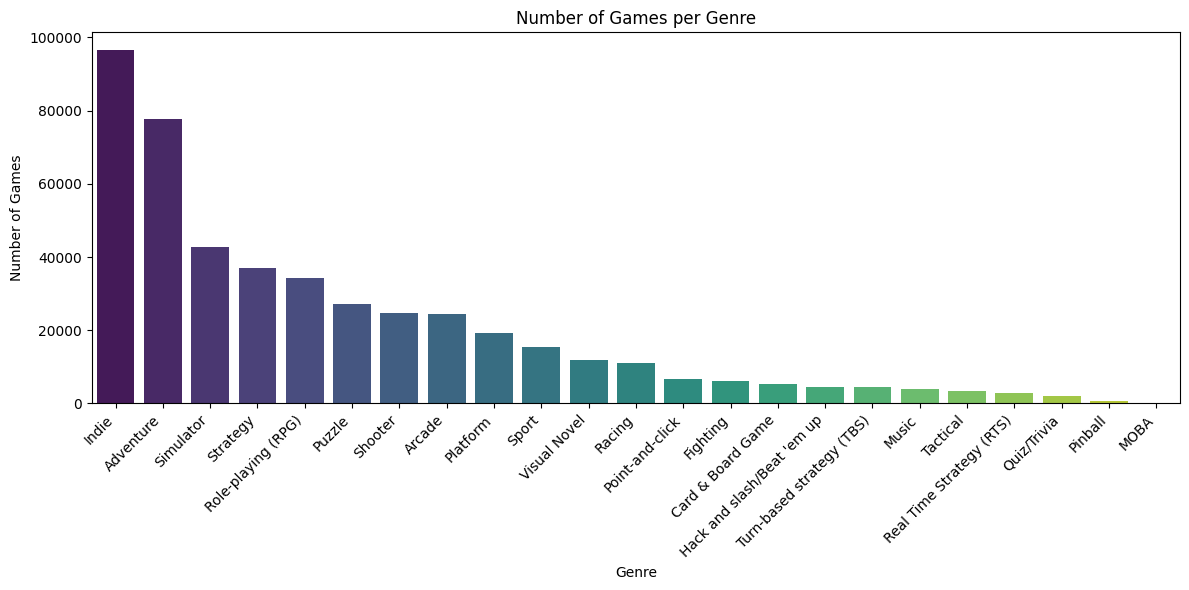

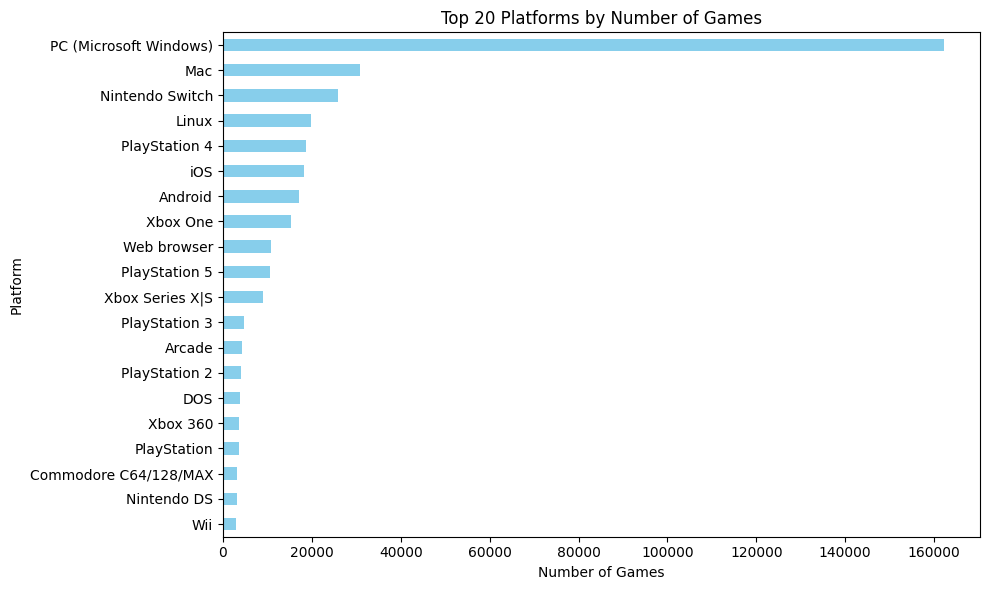

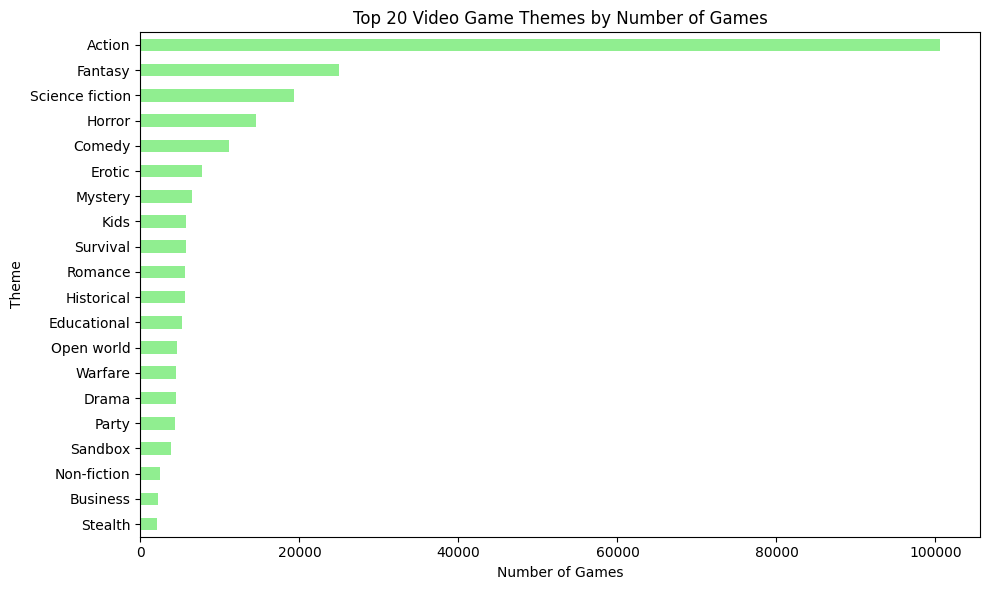

In [21]:
'''
Helper functions for mapping and plotting metadata
'''

def map_genre_names(df, genre_map):
    df = df.copy()
    df["genre_names"] = df["genres"].apply(
        lambda lst: [genre_map.get(g, f"Unknown({g})") for g in lst]
    )
    return df

def map_platform_names(df, platform_map):
    """Map platform IDs in dataframe to readable names."""
    df = df.copy()
    df["platform_names"] = df["platforms"].apply(
        lambda lst: [platform_map.get(p, f"Unknown({p})") for p in lst]
    )
    return df

def map_theme_names(df, theme_map):
    """Map theme IDs in dataframe to readable names."""
    df = df.copy()
    df["theme_names"] = df["themes"].apply(
        lambda lst: [theme_map.get(t, f"Unknown({t})") for t in lst]
    )
    return df

def plot_genre_histogram(df, genre_map):
    df = map_genre_names(df, genre_map)
    all_genres = [g for sublist in df["genre_names"] for g in sublist]
    genre_counts = pd.Series(all_genres).value_counts().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")
    plt.title("Number of Games per Genre")
    plt.xlabel("Genre")
    plt.ylabel("Number of Games")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_platform_histogram(df, platform_map, top_n=20):
    df = map_platform_names(df, platform_map)
    all_platforms = [p for sublist in df["platform_names"] for p in sublist]
    platform_counts = pd.Series(all_platforms).value_counts()
    platform_counts = platform_counts.head(top_n).sort_values()
    
    plt.figure(figsize=(10, 6))
    platform_counts.plot(kind="barh", color="skyblue")
    plt.title(f"Top {top_n} Platforms by Number of Games")
    plt.xlabel("Number of Games")
    plt.ylabel("Platform")
    plt.tight_layout()
    plt.show()

def plot_theme_histogram(df, theme_map, top_n=20):
    df = map_theme_names(df, theme_map)
    all_themes = [t for sublist in df["theme_names"] for t in sublist]
    theme_counts = pd.Series(all_themes).value_counts()
    theme_counts = theme_counts.head(top_n).sort_values()
    
    plt.figure(figsize=(10, 6))
    theme_counts.plot(kind="barh", color="lightgreen")
    plt.title(f"Top {top_n} Video Game Themes by Number of Games")
    plt.xlabel("Number of Games")
    plt.ylabel("Theme")
    plt.tight_layout()
    plt.show()

if BUILD_VISUALIZATION:
    # Plot genre histogram
    plot_genre_histogram(df, genre_map)
    
    # Plot platform histogram
    plot_platform_histogram(df, platform_map, top_n=20)
    
    # Plot theme histogram
    plot_theme_histogram(df, theme_map, top_n=20)
else:
    print("Skipping genre, platform, and theme histograms (BUILD_VISUALIZATION=False)")

In [22]:
'''
Map genre and theme names (unconditional - required for all downstream analysis)
'''
# Ensure genres/themes are lists of ints
list_cols = ["genres", "themes"]
for col in list_cols:
    def to_list(x):
        if isinstance(x, list):
            return x  # already a list
        elif pd.isna(x) or x == "":
            return []
        else:
            return [int(v) for v in x.split(",")]
    df[col] = df[col].apply(to_list)

# Map genres and themes to human-readable names
df["genre_names"] = df["genres"].apply(lambda lst: [genre_map.get(g, f"Unknown({g})") for g in lst])
df["theme_names"] = df["themes"].apply(lambda lst: [theme_map.get(t, f"Unknown({t})") for t in lst])

print(f"Mapped genres and themes: {len(df)} games processed")

Mapped genres and themes: 256807 games processed


### Exploring Relationships

We will now explore relationships between columns

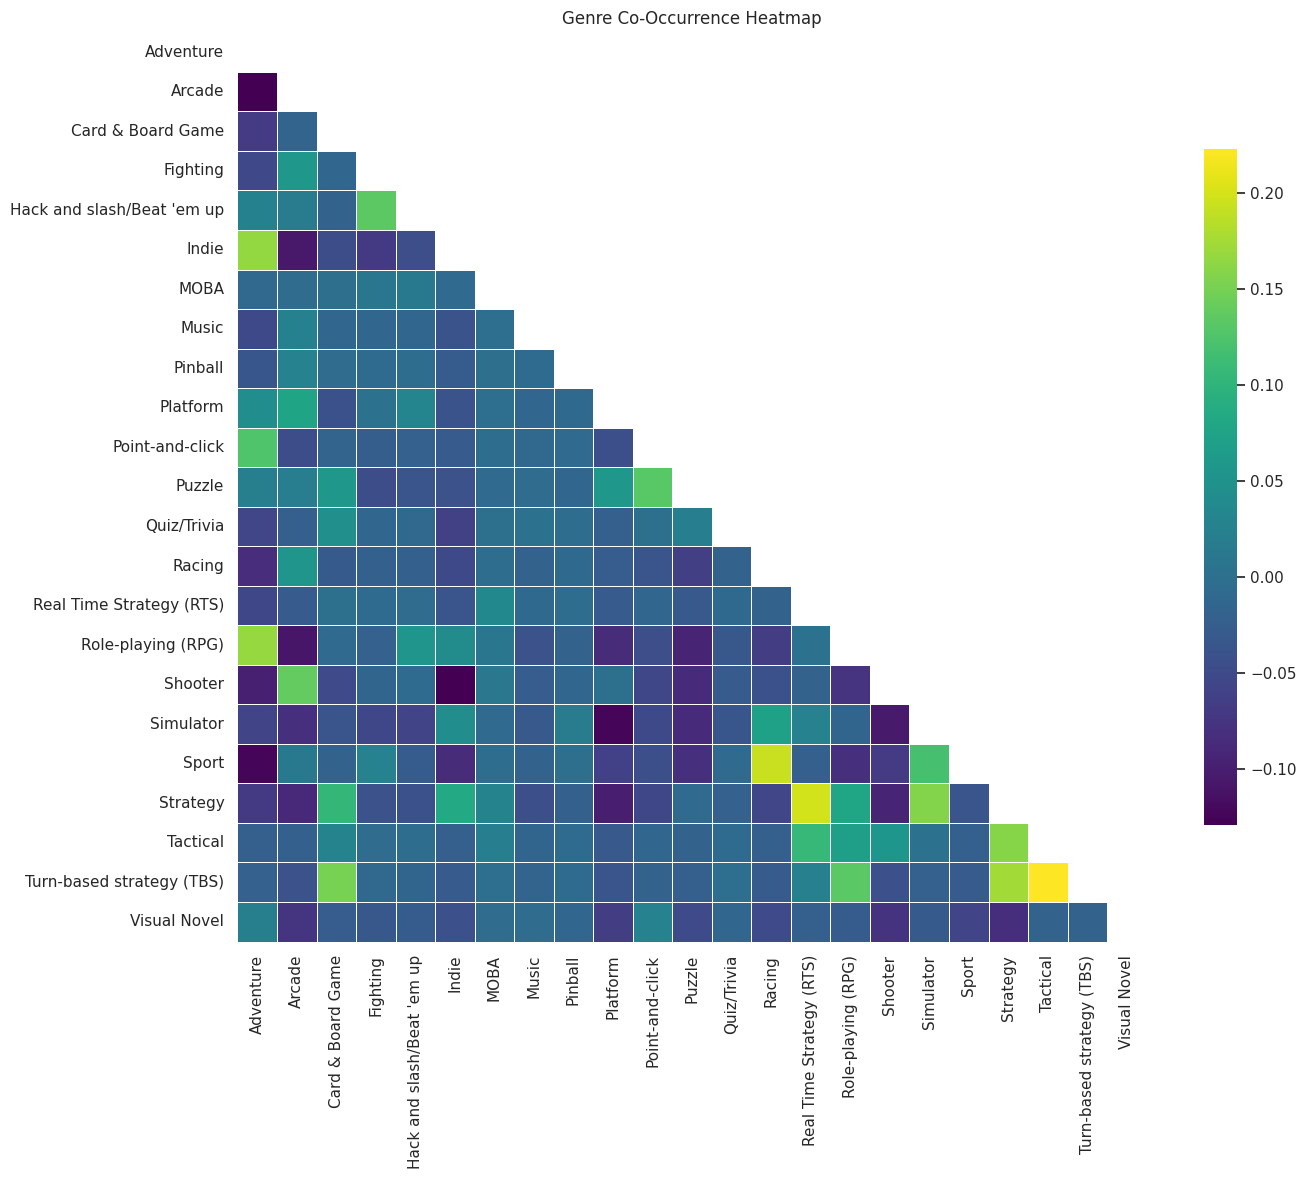

In [23]:
if BUILD_VISUALIZATION:
    '''
    Plot heatmap of genre co-occurrence
    '''
    def genre_heatmap(df):
        df = map_genre_names(df, genre_map)
        df = df[df["genre_names"].apply(lambda x: isinstance(x, list) and len(x) > 0)]
        all_genres = sorted({g for sub in df["genre_names"] for g in sub})
        genre_matrix = pd.DataFrame(0, index=df.index, columns=all_genres)

        for idx, genre_list in df["genre_names"].items():
            genre_matrix.loc[idx, genre_list] = 1

        corr = genre_matrix.corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))

        sns.set_theme(style="white")
        plt.figure(figsize=(14, 12))
        sns.heatmap(
            corr,
            mask=mask,
            cmap="viridis",
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.7},
        )
        plt.title("Genre Co‑Occurrence Heatmap")
        plt.tight_layout()
        plt.show()

    genre_heatmap(df)
else:
    print("Skipping genre co-occurrence heatmap (BUILD_VISUALIZATION=False)")

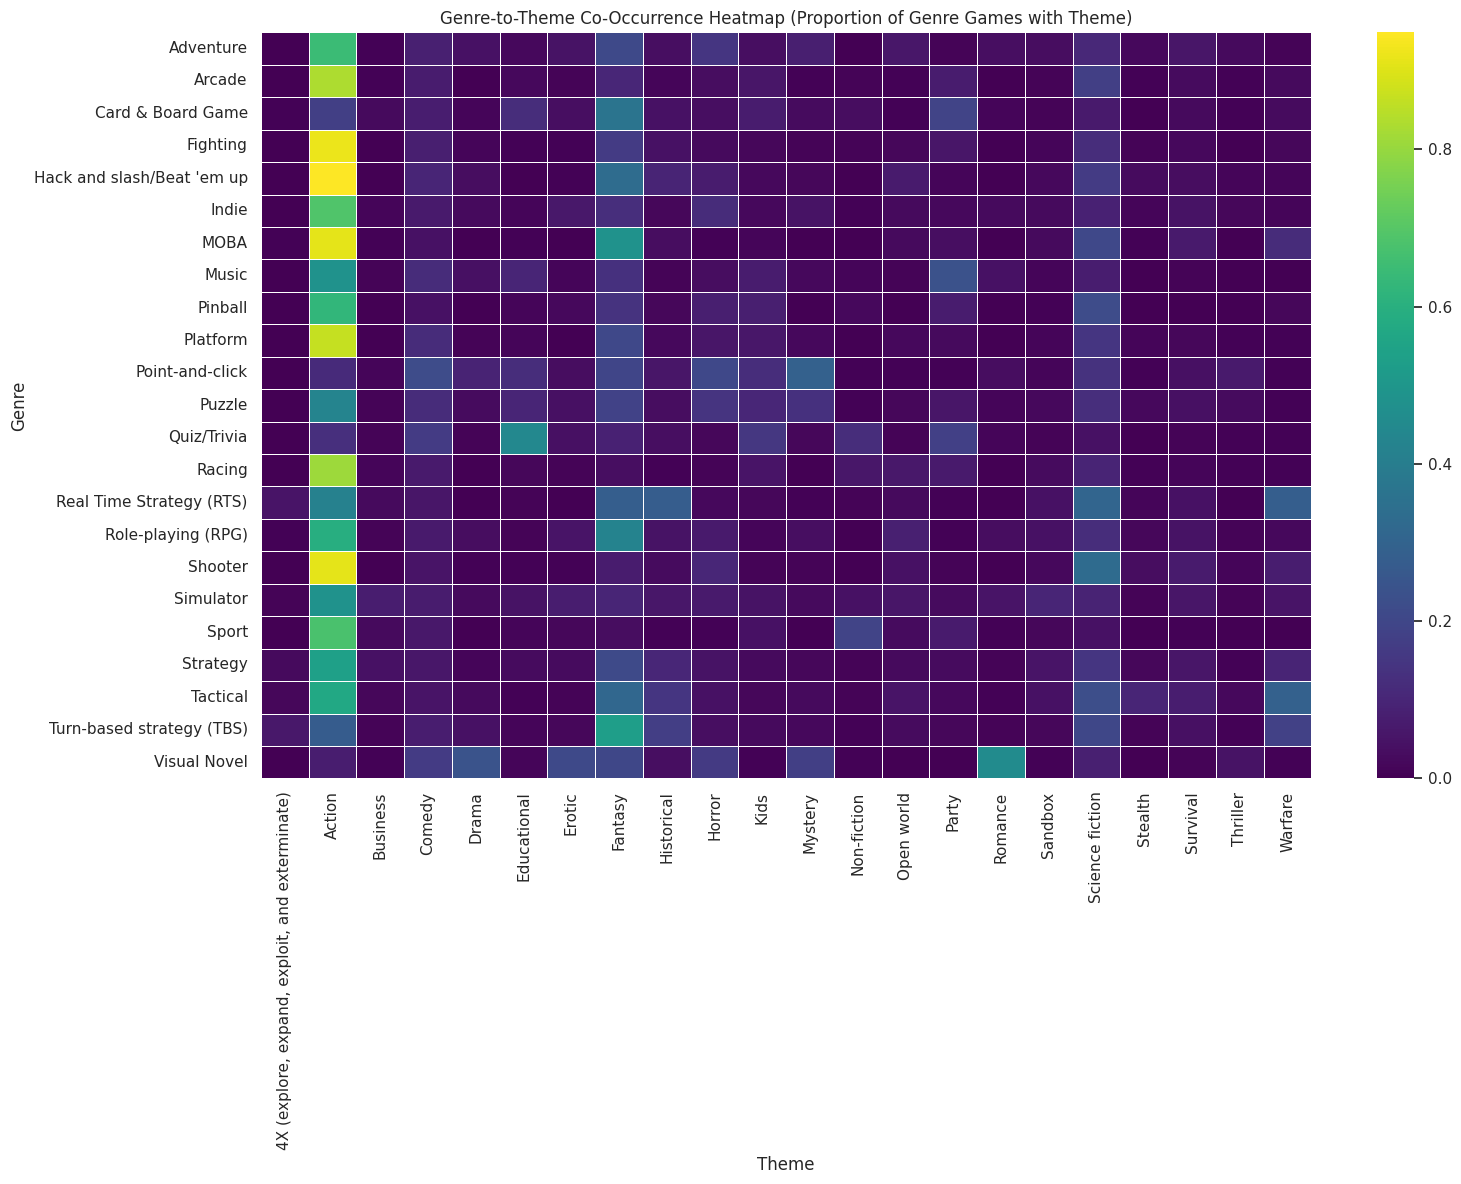

In [24]:
if BUILD_VISUALIZATION:
    # --- Filter out empty ---
    df_viz = df[df["genre_names"].apply(len) > 0]
    df_viz = df_viz[df_viz["theme_names"].apply(len) > 0]

    # --- Binary matrices ---
    all_genres = sorted({g for sub in df_viz["genre_names"] for g in sub})
    all_themes = sorted({t for sub in df_viz["theme_names"] for t in sub})

    genre_matrix = pd.DataFrame(0, index=df_viz.index, columns=all_genres)
    theme_matrix = pd.DataFrame(0, index=df_viz.index, columns=all_themes)

    for idx, g_list in df_viz["genre_names"].items():
        genre_matrix.loc[idx, g_list] = 1

    for idx, t_list in df_viz["theme_names"].items():
        theme_matrix.loc[idx, t_list] = 1

    # --- Compute genre-theme correlation ---
    cooccurrence = genre_matrix.T.dot(theme_matrix)  # genres x themes
    cooccurrence_ratio = cooccurrence.div(genre_matrix.sum(axis=0), axis=0)

    # --- Plot heatmap ---
    plt.figure(figsize=(16, 12))
    sns.heatmap(cooccurrence_ratio, cmap="viridis", linewidths=0.5)
    plt.title("Genre-to-Theme Co-Occurrence Heatmap (Proportion of Genre Games with Theme)")
    plt.xlabel("Theme")
    plt.ylabel("Genre")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping genre-theme co-occurrence heatmap (BUILD_VISUALIZATION=False)")

In [25]:
df.head()

,id,name,first_release_date,genres,platforms,themes,rating,rating_count,total_rating,total_rating_count,summary,storyline,genre_names,theme_names
0,1,Thief II: The Metal Age,2000-03-21,"[5, 13, 31]",[6],"[1, 17, 23]",87.17,147.0,88.59,148.0,The ultimate thief is back! Tread softly as yo...,The game begins as Garrett continues his life ...,"[Shooter, Simulator, Adventure]","[Action, Fantasy, Stealth]"
1,2,Thief: The Dark Project,1998-11-30,"[13, 31]",[6],"[1, 17, 23]",86.41,170.0,78.21,171.0,Thief is a first-person stealth game that like...,NaN,"[Simulator, Adventure]","[Action, Fantasy, Stealth]"
2,3,Thief: Deadly Shadows,2004-05-25,"[5, 13, 31]","[11, 6]","[1, 17, 23]",81.84,128.0,82.42,130.0,"In the third instalment of the Thief series, m...",NaN,"[Shooter, Simulator, Adventure]","[Action, Fantasy, Stealth]"
3,4,Thief,2014-02-25,"[5, 31]","[9, 48, 6, 14, 12, 49]","[1, 23, 33]",69.90,327.0,66.77,341.0,There is a rising tide of fear in The City. Ha...,"Garrett, the Master Thief, steps out of the sh...","[Shooter, Adventure]","[Action, Stealth, Sandbox]"
4,5,Baldur's Gate,1998-12-21,[12],"[3, 6, 39, 14]","[17, 38]",85.69,335.0,85.69,335.0,Baldur's Gate is a fantasy role-playing video ...,Candlekeep is an ancient fortress situated on ...,[Role-playing (RPG)],"[Fantasy, Open world]"


### Investigating the `summary` column and its relationship to other fields

An earlier visualization reveled that the `summary` column had a relatively low "missing data" percent as opposed to the `storyline` column. We want to see how this can be leveraged with other fields to give each game record more "context." Hopefully this will reveal some insights into how we can use the `summary` to predict a user's affinity to certain games they have not played yet.

We will perform dimensionality reduction on the video game summaries, genres, and themes to gain a clearer understanding of the underlying structure of the data. Embeddings generated from game summaries are inherently high-dimensional, which makes direct interpretation and visualization difficult. By reducing the dimensionality, we can project these embeddings into a lower-dimensional space that preserves meaningful semantic relationships while filtering out noise. This enables effective visualization, reveals natural groupings and clusters among games, and helps identify patterns such as genre overlap, thematic similarity, and outliers within the dataset.

>Sources on procedure:
>- [Using T-SNE in Python to Visualize High-Dimensional Data Sets](https://builtin.com/data-science/tsne-python?utm_source=copilot.com)

In [26]:
%pip install nltk
%pip install sentence-transformers
%pip install scikit-learn
%pip install hdbscan
# %pip install umap-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


#### Text Processing
We clean and normalize game summaries to remove punctuation, special characters, extra whitespace, and capitalization differences. This ensures that semantically similar summaries produce similar embeddings, improving the quality of downstream analysis like clustering, t-SNE visualization, and similarity-based recommendations.

In [27]:
import re
import pandas as pd
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    words = text.split()
    return " ".join([w for w in words if w not in stop_words])

df['clean_summary'] = df['summary'].apply(clean_text)

print(df[['summary', 'clean_summary']].head())

[nltk_data] Downloading package stopwords to /home/joseph/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                             summary  \
0  The ultimate thief is back! Tread softly as yo...   
1  Thief is a first-person stealth game that like...   
2  In the third instalment of the Thief series, m...   
3  There is a rising tide of fear in The City. Ha...   
4  Baldur's Gate is a fantasy role-playing video ...   

                                       clean_summary  
0  ultimate thief back tread softly make way 15 n...  
1  thief firstperson stealth game likes dark snea...  
2  third instalment thief series masterthief garr...  
3  rising tide fear city hatred saturates every s...  
4  baldurs gate fantasy roleplaying video game de...  


#### Generate Embeddings
We use Sentence-BERT to convert cleaned game summaries into dense vectors, capturing the game’s semantic meaning beyond just genres or tags. These embeddings are used for clustering, visualization, and similarity-based recommendations.

Check out the [SentenceTransformers Documentation](https://sbert.net/)

Model: [all-MiniLM-L6-v2](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)
>This is a sentence-transformers model: It maps sentences & paragraphs to a 384 dimensional dense vector space and can be used for tasks like clustering or semantic search.

In [28]:
from sentence_transformers import SentenceTransformer

EMBEDDING_PATH = "./embeddings/summary_embeddings.npy"

if os.path.exists(EMBEDDING_PATH):
    print(f"Loading cached embeddings from {EMBEDDING_PATH}")
    summary_embeddings = np.load(EMBEDDING_PATH)
else:
    print(f"Generating summary embeddings ({len(df)} games)...")
    model = SentenceTransformer("all-MiniLM-L6-v2")
    
    summary_embeddings = model.encode(
        df["clean_summary"].tolist(),
        show_progress_bar=True,
        convert_to_numpy=True
    )
    
    np.save(EMBEDDING_PATH, summary_embeddings)
    print(f"Saved embeddings to {EMBEDDING_PATH}")

print("Embedding shape:", summary_embeddings.shape)

Loading cached embeddings from ./embeddings/summary_embeddings.npy
Embedding shape: (256807, 384)


#### Encode Metadata
We convert genres and themes into binary vectors and combine them with the summary embeddings to create the final feature matrix for clustering, visualization, and recommendations.

Check out [`sklearn.preprocessing.MultiLabelBinarizer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MultiLabelBinarizer.html)

In [29]:
from sklearn.preprocessing import MultiLabelBinarizer

assert summary_embeddings.shape[0] == len(df), \
    "Embedding count does not match DataFrame length"

assert not np.isnan(summary_embeddings).any(), \
    "NaNs detected in embeddings"

mlb_genres = MultiLabelBinarizer()
genre_features = mlb_genres.fit_transform(df['genre_names'])

mlb_themes = MultiLabelBinarizer()
theme_features = mlb_themes.fit_transform(df['theme_names'])

# Combine embeddings + metadata
X = np.hstack([summary_embeddings, genre_features, theme_features])
print("Feature matrix shape:", X.shape)

Feature matrix shape: (256807, 429)


#### Visualize Game Clusters (PCA)
We reduce the high-dimensional feature matrix to 2D with PCA to explore overall patterns and clusters among games.

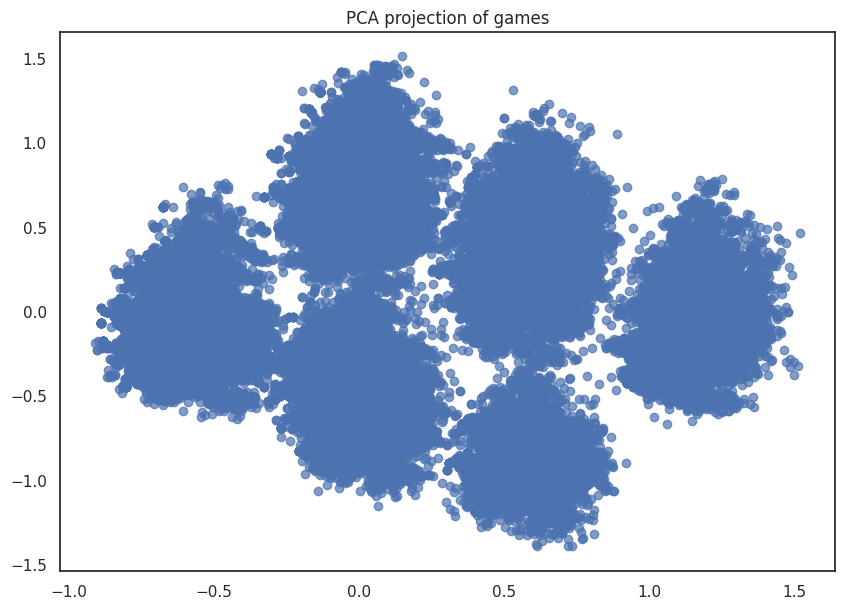

In [30]:
from sklearn.decomposition import PCA

# X = embeddings + metadata
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(10,7))
plt.scatter(X_2d[:,0], X_2d[:,1], alpha=0.7)
plt.title("PCA projection of games")
plt.show()

In [31]:
OBSERVED_NUM_CLUSTERS = 6

#### Cluster the 2D PCA projections
We apply KMeans to the 2D PCA coordinates to group games into clusters and explore common patterns among them.

In [32]:
from sklearn.cluster import KMeans

# Run KMeans on the PCA coordinates
kmeans = KMeans(n_clusters=OBSERVED_NUM_CLUSTERS, random_state=42)
df['pca_cluster'] = kmeans.fit_predict(X_2d)

# Quick check
df['pca_cluster'].value_counts()


pca_cluster
2    84511
1    71097
3    40034
4    24293
5    21014
0    15858
Name: count, dtype: int64

#### Compare Clusters by Metadata
We summarize each PCA cluster by counting the most common genres and themes, calcuating average ratings, and showing sample games to interpret what each cluster represents.

In [33]:
from collections import Counter

for cluster in range(OBSERVED_NUM_CLUSTERS):
    subset = df[df['pca_cluster']==cluster]
    
    # Top genres
    all_genres = [g for sublist in subset['genre_names'] for g in sublist]
    top_genres = Counter(all_genres).most_common(5)
    
    # Top themes
    all_themes = [t for sublist in subset['theme_names'] for t in sublist]
    top_themes = Counter(all_themes).most_common(5)
    
    print(f"Cluster {cluster}:")
    print("  Top Genres:", top_genres)
    print("  Top Themes:", top_themes)
    print("  Avg Rating:", subset['rating'].mean())
    print("  Avg Rating Count:", subset['rating_count'].mean())
    print("  Sample Games:", subset['name'].sample(5).tolist())
    print()


Cluster 0:
  Top Genres: [('Adventure', 10555), ('Shooter', 6073), ('Indie', 5253), ('Arcade', 4379), ('Platform', 3851)]
  Top Themes: [('Action', 15858), ('Science fiction', 3370), ('Fantasy', 2374), ('Horror', 1255), ('Comedy', 1247)]
  Avg Rating: 69.54154658981749
  Avg Rating Count: 88.60668877833056
  Sample Games: ['Blue Blood', 'Mobile Suit Gundam: Crossfire', 'Ratchet & Clank: All 4 One', 'Bioshock 2: Rapture Edition', 'Yaiba: Ninja Gaiden Z']

Cluster 1:
  Top Genres: [('Indie', 52469), ('Adventure', 38723), ('Simulator', 15956), ('Strategy', 13834), ('Role-playing (RPG)', 11842)]
  Top Themes: [('Fantasy', 7816), ('Horror', 6554), ('Erotic', 4236), ('Mystery', 4204), ('Comedy', 3793)]
  Avg Rating: 65.70577561857418
  Avg Rating Count: 20.65653215404459
  Sample Games: ['Prom Night', 'Welcome to Primrose Lake 4', 'The Lost Cave of the Ozarks', 'Lovely Traps Dungeon', 'Soulpath: The Final Journey']

Cluster 2:
  Top Genres: [('Simulator', 15407), ('Strategy', 11336), ('Puzzl

#### Investigate contribution of embeddings vs metadata
We compute the centroid of each cluster separately in embedding space and metadata space to see how much each contributes to the clustering patterns.

In [34]:
df = df.reset_index(drop=True)  # now df.index = 0..N-1
X_embeddings = X[:, :summary_embeddings.shape[1]]
X_metadata = X[:, summary_embeddings.shape[1]:]

centroids_embed = []
centroids_meta = []

for cluster in range(OBSERVED_NUM_CLUSTERS):
    idxs = df[df['pca_cluster']==cluster].index  # now safe
    centroids_embed.append(X_embeddings[idxs].mean(axis=0))
    centroids_meta.append(X_metadata[idxs].mean(axis=0))

print("Cluster centroids (embedding space) shape:", np.array(centroids_embed).shape)
print("Cluster centroids (metadata space) shape:", np.array(centroids_meta).shape)


Cluster centroids (embedding space) shape: (6, 384)
Cluster centroids (metadata space) shape: (6, 45)


In [35]:
from sklearn.metrics.pairwise import cosine_similarity

# Print top genres/themes per cluster
for cluster_id, centroid in enumerate(centroids_meta):
    top_idx = np.argsort(centroid)[::-1][:5]  # top 5 features
    top_features = [mlb_genres.classes_[i] if i < len(mlb_genres.classes_) else mlb_themes.classes_[i - len(mlb_genres.classes_)] for i in top_idx]
    print(f"Cluster {cluster_id} top metadata features:", top_features)

# Find representative games for each cluster (closest to centroid):
for cluster_id in range(OBSERVED_NUM_CLUSTERS):
    idxs = df[df['pca_cluster']==cluster_id].index
    sims = cosine_similarity(X_embeddings[idxs], centroids_embed[cluster_id].reshape(1, -1))
    rep_idx = idxs[sims.argmax()]  # game closest to centroid
    print(f"Cluster {cluster_id} representative game:", df.loc[rep_idx, 'name'])



Cluster 0 top metadata features: ['Action', 'Adventure', 'Shooter', 'Indie', 'Arcade']
Cluster 1 top metadata features: ['Indie', 'Adventure', 'Simulator', 'Strategy', 'Role-playing (RPG)']
Cluster 2 top metadata features: ['Simulator', 'Strategy', 'Puzzle', 'Sport', 'Role-playing (RPG)']
Cluster 3 top metadata features: ['Action', 'Shooter', 'Arcade', 'Science fiction', 'Platform']
Cluster 4 top metadata features: ['Action', 'Indie', 'Adventure', 'Role-playing (RPG)', 'Strategy']
Cluster 5 top metadata features: ['Indie', 'Action', 'Adventure', 'Role-playing (RPG)', 'Simulator']
Cluster 0 representative game: Squad Killer
Cluster 1 representative game: Tyd wag vir Niemand
Cluster 2 representative game: Mega Miracle Force
Cluster 3 representative game: Hard Corps: Uprising
Cluster 4 representative game: Match In Peace
Cluster 5 representative game: Lenna's Inception


#### t-SNE (t-distributed Stochastic Neighbor Embedding)
Based on the above outputs, it's still not fine grained enough to make any meaningful insights. So lets continue with some further exploration...

We use t-SNE to project the high-dimensional embeddings and metadata into 2D, revealing fine-grained clusters and substructures that PCA may miss, with points colored by the PCA cluster assignments.

> Helpful Video Refresher: [StatQuest: t-SNE, Clearly Explained](https://www.youtube.com/watch?v=NEaUSP4YerM)

> A denser video... [Latent Space Visualisation: PCA, t-SNE, UMAP | Deep Learning Animated](https://www.youtube.com/watch?v=o_cAOa5fMhE)

Reducing dimensionality with PCA...

Processing t-SNE with params: {'perplexity': 40, 'learning_rate': 700, 'metric': 'cosine', 'init': 'pca'}
Found existing t-SNE → loading ./tsne_coords/X_tsne_perp40_lr700_metriccosine.npy


/tmp/ipykernel_8728/2732852530.py:67: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.scatterplot(


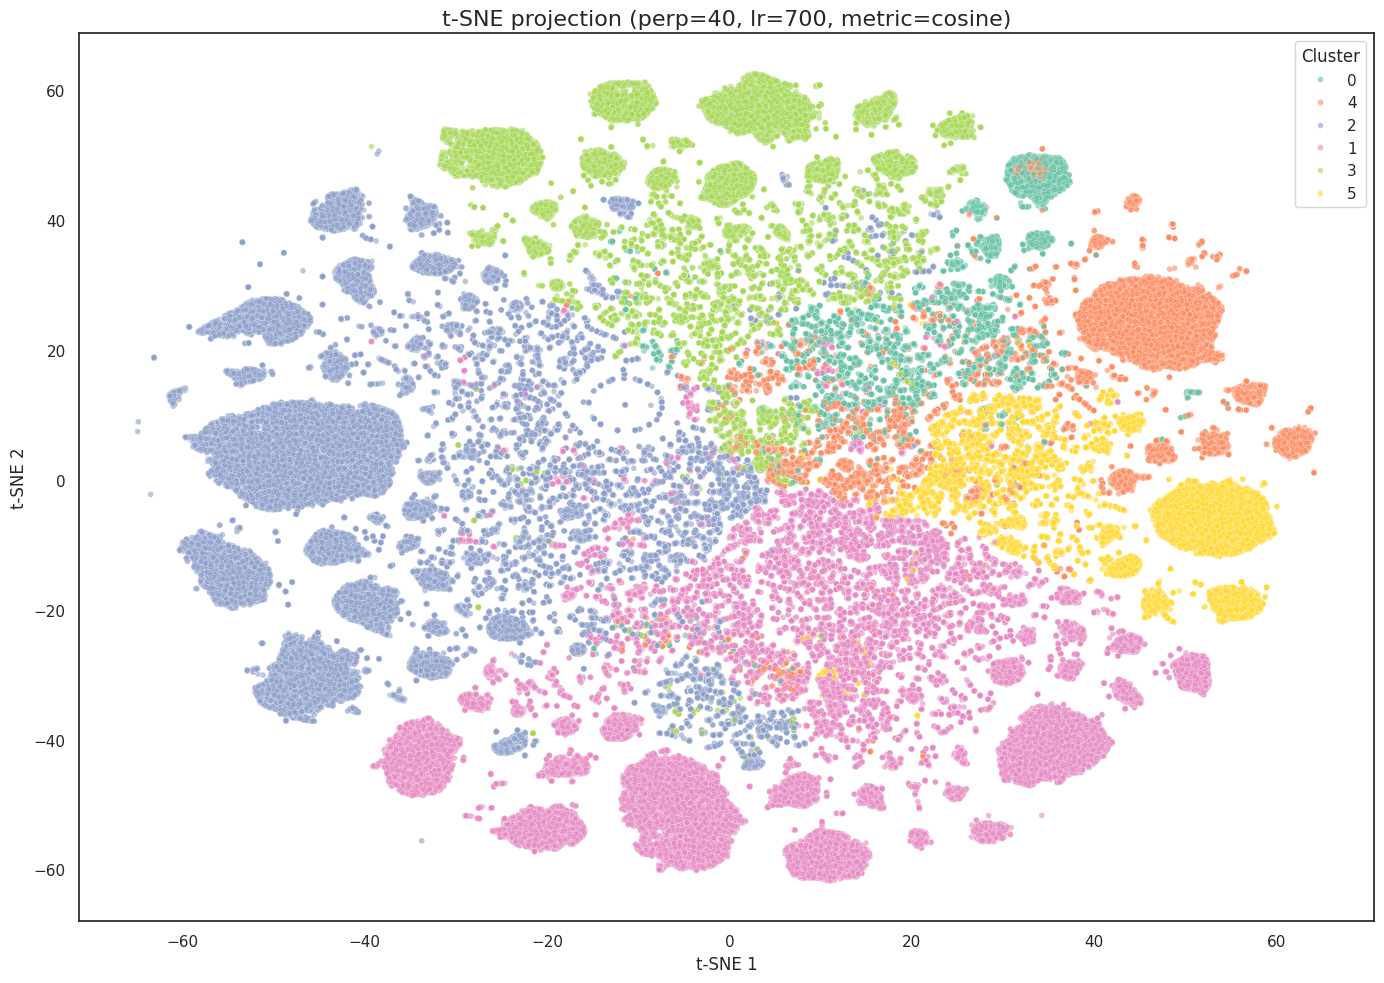

Saved figure: ./figures/tsne_perp40_lr700_metriccosine.png


In [36]:
from sklearn.manifold import TSNE
import os

# --- Ensure output directories exist ---
FIGURES_DIR = "./figures"
TSNE_DIR = "./tsne_coords"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TSNE_DIR, exist_ok=True)

# --- t-SNE configs ---
tsne_configs = [
    {"perplexity": 40, "learning_rate": 700, "metric": "cosine", "init": "pca"},
]

# --- PCA reduction first (CPU) ---
print("Reducing dimensionality with PCA...")
from sklearn.decomposition import PCA
pca_for_tsne = PCA(n_components=50, random_state=42)
X_pca50 = pca_for_tsne.fit_transform(X)

# --- Helper: find cached t-SNE file ---
def find_existing_tsne(cfg, directory):
    expected_name = (
        f"X_tsne_perp{cfg['perplexity']}_"
        f"lr{cfg['learning_rate']}_"
        f"metric{cfg['metric']}.npy"
    )
    for fname in os.listdir(directory):
        if fname == expected_name:
            return os.path.join(directory, fname)
    return None

# --- Loop through configurations ---
for cfg in tsne_configs:
    print(f"\nProcessing t-SNE with params: {cfg}")

    existing_tsne_path = find_existing_tsne(cfg, TSNE_DIR)

    # --- Load or compute ---
    if existing_tsne_path is not None:
        print(f"Found existing t-SNE → loading {existing_tsne_path}")
        X_tsne = np.load(existing_tsne_path)
    else:
        print("No cached result found — running t-SNE on CPU...")
        tsne = TSNE(
            n_components=2,
            perplexity=cfg["perplexity"],
            learning_rate=cfg["learning_rate"],
            init=cfg["init"],
            metric=cfg["metric"],
            random_state=42
        )

        X_tsne = tsne.fit_transform(X_pca50)

        save_path = os.path.join(
            TSNE_DIR,
            f"X_tsne_perp{cfg['perplexity']}_"
            f"lr{cfg['learning_rate']}_"
            f"metric{cfg['metric']}.npy"
        )
        np.save(save_path, X_tsne)
        print(f"Saved t-SNE coordinates to {save_path}")

    # --- Plot ---
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        x=X_tsne[:, 0],
        y=X_tsne[:, 1],
        hue=df["pca_cluster"].astype(str),
        palette=sns.color_palette("Set2"),
        alpha=0.6,
        s=18,
        edgecolor="w",
        linewidth=0.25
    )

    title = (
        f"t-SNE projection (perp={cfg['perplexity']}, "
        f"lr={cfg['learning_rate']}, metric={cfg['metric']})"
    )
    plt.title(title, fontsize=16)
    plt.xlabel("t-SNE 1", fontsize=12)
    plt.ylabel("t-SNE 2", fontsize=12)
    plt.legend(title="Cluster", loc="best")
    plt.tight_layout()

    fig_path = os.path.join(
        FIGURES_DIR,
        f"tsne_perp{cfg['perplexity']}_"
        f"lr{cfg['learning_rate']}_"
        f"metric{cfg['metric']}.png"
    )
    plt.savefig(fig_path, dpi=200)
    plt.show()
    plt.close()

    print(f"Saved figure: {fig_path}")


#### Subcluster Discovery with HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)

t-SNE can visually exaggerate small neighborhoods, so we apply HDBSCAN directly to the original embedding space to identify density-based subclusters. If the visually apparent islands correspond to HDBSCAN labels, this suggests the structure is intrinsic to the data rather than a visualization artifact.

In [37]:
'''
Load cached t-SNE coordinates and prepare for HDBSCAN
This allows running HDBSCAN directly without re-computing t-SNE
'''
from sklearn.preprocessing import StandardScaler, normalize
import hdbscan

# Load cached t-SNE coordinates
TSNE_PATH = "./tsne_coords/X_tsne_perp40_lr700_metriccosine.npy"
if os.path.exists(TSNE_PATH):
    print(f"Loading cached t-SNE coordinates from {TSNE_PATH}")
    X_tsne = np.load(TSNE_PATH)
    print(f"Loaded t-SNE shape: {X_tsne.shape}")
else:
    print(f"Warning: {TSNE_PATH} not found. Run t-SNE cell first.")
    X_tsne = None

Loading cached t-SNE coordinates from ./tsne_coords/X_tsne_perp40_lr700_metriccosine.npy
Loaded t-SNE shape: (256807, 2)


In [38]:
# --- Feature scaling: embeddings ---
# L2-normalize embeddings for cosine similarity
X_embeddings_normalized = normalize(summary_embeddings, axis=1, norm='l2')
print(f"Embeddings normalized: {X_embeddings_normalized.shape}")

Embeddings normalized: (256807, 384)


In [39]:
# --- Feature scaling: metadata ---
scaler_genres = StandardScaler(with_mean=False)  # sparse-friendly
scaler_themes = StandardScaler(with_mean=False)

X_genres_scaled = scaler_genres.fit_transform(genre_features)
X_themes_scaled = scaler_themes.fit_transform(theme_features)

print(f"Genres scaled: {X_genres_scaled.shape}")
print(f"Themes scaled: {X_themes_scaled.shape}")

Genres scaled: (256807, 23)
Themes scaled: (256807, 22)


In [40]:
# --- Combine embeddings + metadata ---
X_combined = np.hstack([X_embeddings_normalized, X_genres_scaled, X_themes_scaled])
print(f"Combined feature matrix shape: {X_combined.shape}")
print(f"  Embeddings: {X_embeddings_normalized.shape[1]}")
print(f"  Genres: {X_genres_scaled.shape[1]}")
print(f"  Themes: {X_themes_scaled.shape[1]}")

# Optional: check feature scaling balance
col_norms = np.linalg.norm(X_combined, axis=0)
print(f"Feature norm stats: min={col_norms.min():.4f}, max={col_norms.max():.4f}, mean={col_norms.mean():.4f}")

Combined feature matrix shape: (256807, 429)
  Embeddings: 384
  Genres: 23
  Themes: 22
Feature norm stats: min=0.0000, max=649.7093, mean=77.7913


In [41]:
# --- Adaptive HDBSCAN parameters ---
dataset_size = len(df)
min_cluster_size = max(30, int(dataset_size * 0.005))
min_samples = 10  # can also adapt: max(5, int(dataset_size * 0.01))

hdb = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    metric="euclidean",
    cluster_selection_epsilon=0.0
)

print(f"HDBSCAN parameters: min_cluster_size={min_cluster_size}, min_samples={min_samples}, metric='euclidean'")

HDBSCAN parameters: min_cluster_size=1284, min_samples=10, metric='euclidean'


In [42]:

from cuml.cluster import HDBSCAN
labels = HDBSCAN().fit_predict(X_combined)
df["subcluster"] = labels
print("HDBSCAN clustering complete!")

[2026-01-26 16:33:34.320] [CUML] [warning] Using data on device memory because knn_n_clusters = 1.
HDBSCAN clustering complete!


In [44]:
subcluster_counts = df["subcluster"].value_counts().sort_index()
n_clusters = (subcluster_counts.index >= 0).sum()
n_noise = subcluster_counts.get(-1, 0)

print(f"\nClustering Results:")
print(f"  Valid clusters: {n_clusters}")
print(f"  Noise points: {n_noise if n_noise > 0 else 'None'}")
print(f"\nCluster distribution:\n{subcluster_counts}")


Clustering Results:
  Valid clusters: 4723
  Noise points: 68758

Cluster distribution:
subcluster
-1       68758
 0         147
 1          55
 2          25
 3           7
         ...  
 4718        6
 4719        6
 4720        8
 4721        6
 4722        6
Name: count, Length: 4724, dtype: int64


#### Subcluster Validation via t-SNE Recoloring
By recoloring the existing t-SNE projection using the HDBSCAN subcluster labels, we can visually assess whether the detected subclusters align with the observed islands. Strong alignment indicates meaningful local structure in the embedding space.

/tmp/ipykernel_8728/2619876648.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Subcluster", bbox_to_anchor=(1.05, 1), loc="upper left")


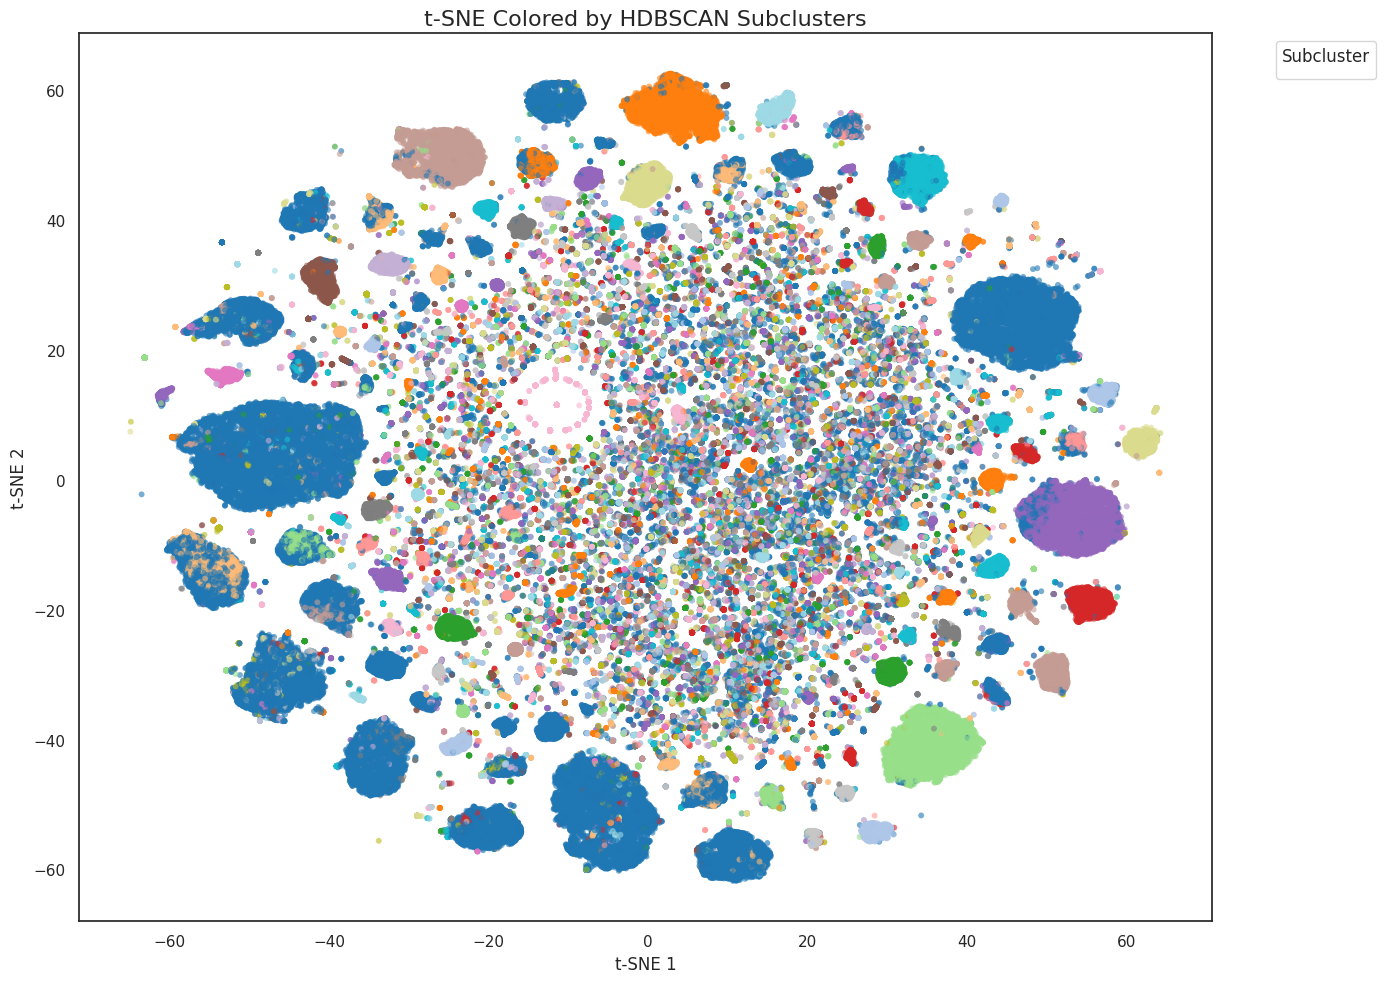

In [45]:
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=df["subcluster"].astype(str),
    palette="tab20",
    alpha=0.6,
    s=18,
    linewidth=0,
    legend=False
)
plt.title("t-SNE Colored by HDBSCAN Subclusters", fontsize=16)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Subcluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


#### Representative Games per Subcluster (Semantic Inspection)
To understand what defines each subcluster, we inspect representative games with high popularity or relevance. This provides qualitative validation by revealing shared genres, themes, or narrative styles.

In [46]:
def show_examples(subcluster_id, n=5):
    subset = df[df.subcluster == subcluster_id].sort_values(
        "rating", ascending=False
    )
    display(subset[["name", "genres", "themes", "summary"]].head(n))

# Output example for a few subclusters
OUTPUT_SUBCLUSTERS = 3
count = 0

for sc in sorted(df["subcluster"].unique()):
    if count >= OUTPUT_SUBCLUSTERS:
        break
    if sc == -1:
        continue
    print(f"\nSubcluster {sc}")
    show_examples(sc)
    count += 1


Subcluster 0


,name,genres,themes,summary
746,Heroes of Newerth,"[25, 36]","[1, 17, 22]",Heroes of Newerth builds upon the DotA formula...
38797,Honor of Kings,"[15, 36]",[17],Honor of Kings (also translated as King of Glo...
81696,Predecessor,"[5, 15, 36]","[1, 18]","Inspired by the legacy of Paragon, built with ..."
195350,Wild Assault,"[5, 24, 31, 36]","[1, 17, 39]",Wild Assault is an anthro-themed tactical shoo...
199117,Shape of Dreams,"[15, 24, 25, 31, 32, 36]","[1, 17]",Shape of Dreams is an action rogue-lite infuse...



Subcluster 1


,name,genres,themes,summary
9110,Poseidon: Master of Atlantis,[11],"[17, 22, 28, 39]",Poseidon is an expansion to Zeus: Master of Ol...
8093,Startopia,"[11, 13, 15]","[18, 28]",A once thriving network of space stations and ...
193912,MegaWorld,"[11, 12, 15]","[28, 38]",Autonomous Web3 city builder game.\n\nConstruc...
134715,Supremacy: The Metaverse Game,"[4, 11, 13, 15, 24]","[1, 18, 28, 39]",Supremacy is a collection of games that connec...
47052,Anno 1800,"[11, 13, 15]","[22, 28]",Anno 1800: Lead the Industrial Revolution! Wel...



Subcluster 2


,name,genres,themes,summary
5348,Awesomenauts Assemble!,"[8, 11, 15, 36]","[1, 18, 39]",Awesomenauts Assemble! is a conversion of the ...
213590,Dragon Ball Gekishin Squadra,"[11, 36]",[1],“This brand‑new title is a battle arena game t...
20475,Battlerite,"[4, 11, 15, 25, 36]","[1, 17]",Battlerite is a Team Arena Brawler focused on ...
94440,Rover Wars: Battle For Mars,"[11, 13, 15, 32, 36]","[1, 18, 39, 40]",What if MOBAs and RTS games had a baby? Rover ...
5325,Strife,"[11, 12, 15, 25, 36]","[1, 17]",Strife pits two teams of players against each ...


#### Keyword Extraction for Subcluster Interpretation
We extract prominent terms from game summaries within each subcluster using TF-IDF (Term Frequency-Inverse Document Frequency) to generate concise semantic descriptors. This allows subclusters to be summarized and labeled in a reproducible, human-interpretable way.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# --- Ensure output directory exists ---
OUT_DIR = "subclustering"
os.makedirs(OUT_DIR, exist_ok=True)

def top_terms_for_cluster(cluster_id, k=10):
    texts = df[df.subcluster == cluster_id]["summary"].dropna()
    if len(texts) < 5:
        return []

    vec = TfidfVectorizer(
        stop_words="english",
        max_features=2000
    )
    X_tfidf = vec.fit_transform(texts)
    scores = np.asarray(X_tfidf.mean(axis=0)).ravel()
    terms = vec.get_feature_names_out()

    return sorted(zip(terms, scores), key=lambda x: -x[1])[:k]

# --- Build dictionary of keywords ---
cluster_keywords = {}

num_subclusters = len(df["subcluster"].unique())

for sc in sorted(df["subcluster"].unique()):
    if sc == -1:
        continue
    keywords = [t for t, _ in top_terms_for_cluster(sc)]
    cluster_keywords[str(sc)] = keywords
    print(f"Subcluster {sc} keywords: {keywords}")

# --- Save JSON ---
json_path = os.path.join(OUT_DIR, "keywords.json")
with open(json_path, "w") as f:
    json.dump(cluster_keywords, f, indent=4)

print(f"Saved keyword JSON to {json_path}. It has {num_subclusters} subclusters.")

Subcluster 0 keywords: ['game', 'moba', 'battle', 'team', 'arena', 'multiplayer', 'character', 'players', 'play', 'action']
Subcluster 1 keywords: ['game', 'new', 'world', 'city', 'build', 'tycoon', 'play', 'building', 'time', 'players']
Subcluster 2 keywords: ['game', 'moba', 'battle', 'online', 'arena', 'heroes', 'strategy', 'play', 'gameloft', 'war']
Subcluster 3 keywords: ['railway', 'empire', 'company', 'cities', 'india', 'bridges', 'tracks', 'maps', 'east', 'continent']
Subcluster 4 keywords: ['make', 'atelier', 'japan', 'marie', 'phones', 'plus', 'port', 'vodafone', 'west', 'park']
Subcluster 5 keywords: ['game', 'music', 'sandbox', 'musical', 'virtual', 'garden', 'create', 'world', 'sounds', 'built']
Subcluster 6 keywords: ['pinball', 'game', 'sonic', 'kirby', 'table', 'world', 'annoying', 'orange', 'enemies', 'adventure']
Subcluster 7 keywords: ['game', 'new', 'shooter', 'tactical', 'player', 'war', 'players', 'person', 'returns', 'shadowrun']
Subcluster 8 keywords: ['solve', 

: 

#### Projection Robustness Check with UMAP
Because t-SNE emphasizes local structure, we validate the persistence of subclusters using UMAP, which better preserves global relationships. Subclusters that remain coherent across both projections are more likely to represent genuine semantic groupings.

In [ ]:
import umap
import time

UMAP_PATH = "./embeddings/umap_embeddings.npy"

# --- Load cached or compute UMAP ---
if os.path.exists(UMAP_PATH):
    print(f"Loading cached UMAP embeddings from {UMAP_PATH}")
    umap_emb = np.load(UMAP_PATH)
else:
    print("Running UMAP projection...")
    start_time = time.time()
    
    # --- Step 1: Dimensionality reduction with PCA for speed ---
    print("  Reducing dimensionality with PCA...")
    pca_umap = PCA(n_components=50, random_state=42)
    X_pca = pca_umap.fit_transform(X)
    print(f"  PCA reduced {X.shape[1]} → {X_pca.shape[1]} dimensions")
    
    # --- Step 2: Optimized UMAP computation ---
    umap_emb = umap.UMAP(
        n_neighbors=15,           # reduced from 30 (trade-off: faster, still captures local structure)
        min_dist=0.15,            # slightly increased from 0.1 (minor speed gain, more spread)
        metric="cosine",          # cosine is efficient with normalized embeddings
        random_state=42,          # reproducibility
        n_jobs=-1,                # use all CPU cores
        low_memory=False,         # allow more aggressive optimization
        verbose=1
    ).fit_transform(X_pca)       # compute on PCA-reduced data
    
    elapsed = time.time() - start_time
    print(f"UMAP computation completed in {elapsed:.1f} seconds")
    
    np.save(UMAP_PATH, umap_emb)
    print(f"Saved UMAP embeddings to {UMAP_PATH}")

# --- Visualize with HDBSCAN subclusters ---
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x=umap_emb[:, 0],
    y=umap_emb[:, 1],
    hue=df["subcluster"].astype(str),
    palette="tab20",
    alpha=0.6,
    s=18,
    linewidth=0
)
plt.title("UMAP Projection Colored by HDBSCAN Subclusters", fontsize=16)
plt.xlabel("UMAP 1", fontsize=12)
plt.ylabel("UMAP 2", fontsize=12)
plt.legend(title="Subcluster", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nUMAP shape: {umap_emb.shape}")
print(f"Number of subclusters detected: {len(set(df['subcluster'])) - (1 if -1 in set(df['subcluster']) else 0)}")

Running UMAP projection...


/home/joseph/GameScope/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=1)


#### Quantifying Subcluster Cohesion in Embedding Space
To quantitatively assess subcluster quality, we compute average intra-cluster cosine distance. Lower values indicate tighter semantic cohesion and stronger justification for treating a subcluster as a meaningful group.

In [ ]:
from sklearn.metrics import pairwise_distances

D = pairwise_distances(X, metric="cosine")

def intra_cluster_distance(labels):
    results = {}
    for c in set(labels):
        if c == -1:
            continue
        idx = np.where(labels == c)[0]
        if len(idx) < 2:
            continue
        results[c] = D[np.ix_(idx, idx)].mean()
    return results

intra_distances = intra_cluster_distance(df["subcluster"].values)
intra_distances

#### Correlation Analysis: Embeddings vs Metadata
To quantify the relationship between semantic structure (embeddings) and categorical metadata (genres/themes), we compute Spearman and Pearson correlations. This reveals whether embeddings naturally align with existing categorizations or capture independent semantic dimensions.


In [ ]:
from scipy.stats import spearmanr, pearsonr
from scipy.spatial.distance import pdist

# --- PCA embedding compression for correlation analysis ---
# Use PCA-reduced embeddings (50 components) for manageable correlation matrix
pca_embed = PCA(n_components=20, random_state=42)
X_embed_pca = pca_embed.fit_transform(X_embeddings_normalized)

print("Computing correlations between PCA embedding components and metadata features...")
print(f"Embedding shape (PCA): {X_embed_pca.shape}")
print(f"Genre features shape: {genre_features.shape}")
print(f"Theme features shape: {theme_features.shape}")

# --- Compute Spearman correlations ---
# Spearman is robust to outliers and doesn't assume linearity
spearman_corrs_genres = []
spearman_corrs_themes = []

for i in range(X_embed_pca.shape[1]):
    embed_comp = X_embed_pca[:, i]
    
    # Genre correlations
    for j in range(genre_features.shape[1]):
        corr, p_val = spearmanr(embed_comp, genre_features[:, j])
        spearman_corrs_genres.append({
            'embedding_pc': i,
            'feature': mlb_genres.classes_[j],
            'correlation': corr,
            'p_value': p_val
        })
    
    # Theme correlations
    for j in range(theme_features.shape[1]):
        corr, p_val = spearmanr(embed_comp, theme_features[:, j])
        spearman_corrs_themes.append({
            'embedding_pc': i,
            'feature': mlb_themes.classes_[j],
            'correlation': corr,
            'p_value': p_val
        })

spearman_genres_df = pd.DataFrame(spearman_corrs_genres)
spearman_themes_df = pd.DataFrame(spearman_corrs_themes)

# Filter for significant correlations (p < 0.05)
sig_genres = spearman_genres_df[spearman_genres_df['p_value'] < 0.05]
sig_themes = spearman_themes_df[spearman_themes_df['p_value'] < 0.05]

print(f"\nSignificant Spearman Correlations (p < 0.05):")
print(f"  Genres: {len(sig_genres)} / {len(spearman_genres_df)}")
print(f"  Themes: {len(sig_themes)} / {len(spearman_themes_df)}")

# --- Top correlations ---
print("\n--- Top 10 Genre-Embedding Correlations (by absolute value) ---")
top_genre_corrs = spearman_genres_df.loc[spearman_genres_df['correlation'].abs().nlargest(10).index]
print(top_genre_corrs[['embedding_pc', 'feature', 'correlation']].to_string(index=False))

print("\n--- Top 10 Theme-Embedding Correlations (by absolute value) ---")
top_theme_corrs = spearman_themes_df.loc[spearman_themes_df['correlation'].abs().nlargest(10).index]
print(top_theme_corrs[['embedding_pc', 'feature', 'correlation']].to_string(index=False))

# --- Visualize correlation heatmap ---
# Create pivot tables for heatmaps (only top features to keep readable)
top_n_genres = 15
top_n_themes = 15

# Find most variable/informative genres and themes
genre_vars = genre_features.var(axis=0)
theme_vars = theme_features.var(axis=0)

top_genre_idxs = np.argsort(genre_vars)[-top_n_genres:]
top_theme_idxs = np.argsort(theme_vars)[-top_n_themes:]

# Build correlation matrices for top features
corr_embed_genres = np.zeros((X_embed_pca.shape[1], len(top_genre_idxs)))
corr_embed_themes = np.zeros((X_embed_pca.shape[1], len(top_theme_idxs)))

for i in range(X_embed_pca.shape[1]):
    for j, genre_idx in enumerate(top_genre_idxs):
        corr, _ = spearmanr(X_embed_pca[:, i], genre_features[:, genre_idx])
        corr_embed_genres[i, j] = corr
    
    for j, theme_idx in enumerate(top_theme_idxs):
        corr, _ = spearmanr(X_embed_pca[:, i], theme_features[:, theme_idx])
        corr_embed_themes[i, j] = corr

# Plot genre-embedding correlations
fig, ax = plt.subplots(figsize=(12, 8))
genre_labels = [mlb_genres.classes_[i] for i in top_genre_idxs]
sns.heatmap(
    corr_embed_genres,
    xticklabels=genre_labels,
    yticklabels=[f"PC {i}" for i in range(X_embed_pca.shape[1])],
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Spearman Correlation"},
    ax=ax
)
ax.set_title("Spearman Correlation: Embedding PCs vs Top Genres", fontsize=14)
ax.set_xlabel("Genre")
ax.set_ylabel("Embedding Principal Component")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot theme-embedding correlations
fig, ax = plt.subplots(figsize=(12, 8))
theme_labels = [mlb_themes.classes_[i] for i in top_theme_idxs]
sns.heatmap(
    corr_embed_themes,
    xticklabels=theme_labels,
    yticklabels=[f"PC {i}" for i in range(X_embed_pca.shape[1])],
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Spearman Correlation"},
    ax=ax
)
ax.set_title("Spearman Correlation: Embedding PCs vs Top Themes", fontsize=14)
ax.set_xlabel("Theme")
ax.set_ylabel("Embedding Principal Component")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Summary: Average correlation strength ---
avg_corr_genres = spearman_genres_df['correlation'].abs().mean()
avg_corr_themes = spearman_themes_df['correlation'].abs().mean()

print(f"\n--- Correlation Strength Summary ---")
print(f"Mean |Spearman Correlation| (Genres): {avg_corr_genres:.4f}")
print(f"Mean |Spearman Correlation| (Themes): {avg_corr_themes:.4f}")
print(f"\nInterpretation:")
print(f"  Low correlations suggest embeddings capture semantic structure")
print(f"  independent of categorical metadata (genres/themes).")
print(f"  High correlations suggest embeddings align with existing categories.")


#### Metadata Overlay for Structural Explanation
Overlaying known metadata such as primary genre, release era, or platform helps explain why certain subclusters form. This often reveals interpretable drivers like genre specialization or temporal trends.

In [ ]:
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=df["primary_genre"],
    alpha=0.6,
    s=18,
    linewidth=0
)
plt.title("t-SNE Colored by Primary Genre", fontsize=16)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()